# Model using a fine-tuned version of VGG16
In this version of the model we use the vgg16 model but we unlock some of the last layers and train those too. This also enables us to use data augmentation again.

In [4]:
import os, shutil, pathlib
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras import Sequential
from keras.utils import image_dataset_from_directory
import numpy as np

original_dir = pathlib.Path("./orig")
new_base_dir = pathlib.Path("./sorted")

In [10]:
# gather datasets
train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size = (180, 180),
    batch_size = 8)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size = (180, 180),
    batch_size = 8)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size = (180, 180),
    batch_size = 8)

Found 88 files belonging to 2 classes.
Found 20 files belonging to 2 classes.
Found 20 files belonging to 2 classes.


In [15]:
# import vgg16 for a convolution base
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base.trainable = True
for layer in conv_base.layers[:-2]:
    layer.trainable = False

conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 2,359,808 (9.00 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

In [16]:
# same data_augmentation as the from scratch -model
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1)
    ]
)

## Model

In [20]:
# build model
model = Sequential([ 
    layers.Input(shape=(180, 180, 3)),
    data_augmentation,
    layers.Lambda(keras.applications.vgg16.preprocess_input),
    conv_base,
    

    layers.Flatten(), 
    layers.Dense(128, activation='relu'),
    
    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid') ]) 

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [21]:
history = model.fit(train_dataset, epochs=10, validation_data=validation_dataset)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.7159 - loss: 5.6962 - val_accuracy: 0.7500 - val_loss: 2.2255
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.8864 - loss: 1.0850 - val_accuracy: 0.8000 - val_loss: 1.9275
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.8636 - loss: 1.4226 - val_accuracy: 1.0000 - val_loss: 0.0247
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.9545 - loss: 0.3934 - val_accuracy: 1.0000 - val_loss: 1.1306e-04
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.9432 - loss: 0.5651 - val_accuracy: 0.8500 - val_loss: 1.7961
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.9091 - loss: 0.9886 - val_accuracy: 1.0000 - val_loss: 2.8807e-04
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.9886 - loss: 0.0508 - val_accuracy: 1.0000 - val_loss: 6.9037e-07
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.9545 - loss: 0.3180 - val_

3/3 - 0s - 79ms/step - accuracy: 0.9500 - loss: 0.2553
Validation loss: 0.25532597303390503
Validation accuracy: 0.949999988079071


Text(0, 0.5, 'Loss')

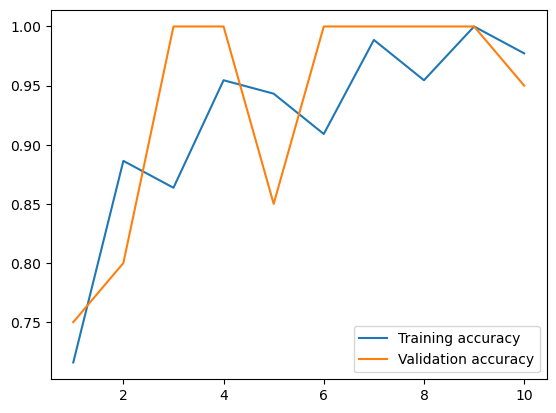

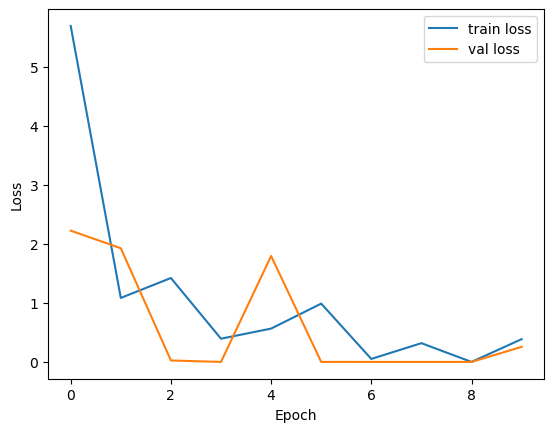

In [22]:
# print validation loss/accuracy
test_scores = model.evaluate(validation_dataset, verbose=2)
print("Validation loss:", test_scores[0])
print("Validation accuracy:", test_scores[1])

# Plot validation loss and accuracy compared to training loss and accuracy
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = list(range(1, len(accuracy)+1))
plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.legend()
plt.figure()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [23]:
# comparing against the test set
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8500 - loss: 3.0243
Test accuracy: 0.850


In [25]:
model.save('fine_tuned_project_2.keras')